In [80]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import griddata

In [81]:
cnames = ['x', 'y', 'z'] #X[nm]		Y[nm]		Z[m]
df = pd.read_csv('195_flatten.txt', skiprows=3, sep='	', header=None, names=cnames)

In [82]:
df.head()

,x,y,z
0,0.000000,0.0,4.143380e-10
1,0.058708,0.0,4.066550e-10
2,0.117417,0.0,4.014850e-10
3,0.176125,0.0,4.013020e-10
4,0.234834,0.0,4.037910e-10


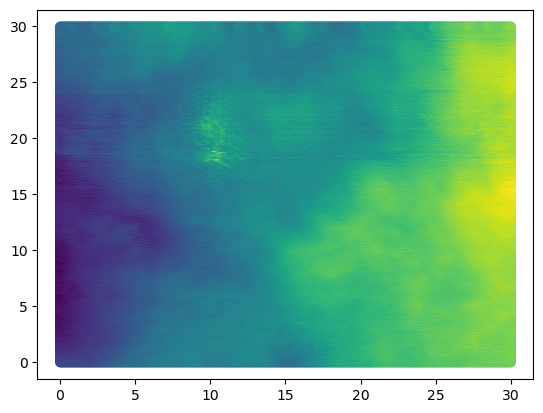

In [83]:
figT, axT = plt.subplots()

axT.scatter(df['x'], df['y'], c=df['z'])

In [84]:
x = np.array(df['x'])

In [85]:
sdf = df[(df['x'] >= 5) & (df['x'] <= 15) & (df['y'] >= 15) & (df['y'] <= 25)]

In [86]:
data = np.vstack((sdf['x'], sdf['y'], sdf['z']))

# Rotation matrix for 90-degree rotation around the Z-axis
R_z = np.array([[0, -1, 0],
                [1,  0, 0],
                [0,  0, 1]])

# Apply the rotation matrix
rotated_data = np.dot(R_z, data)

xr, yr, zr = rotated_data


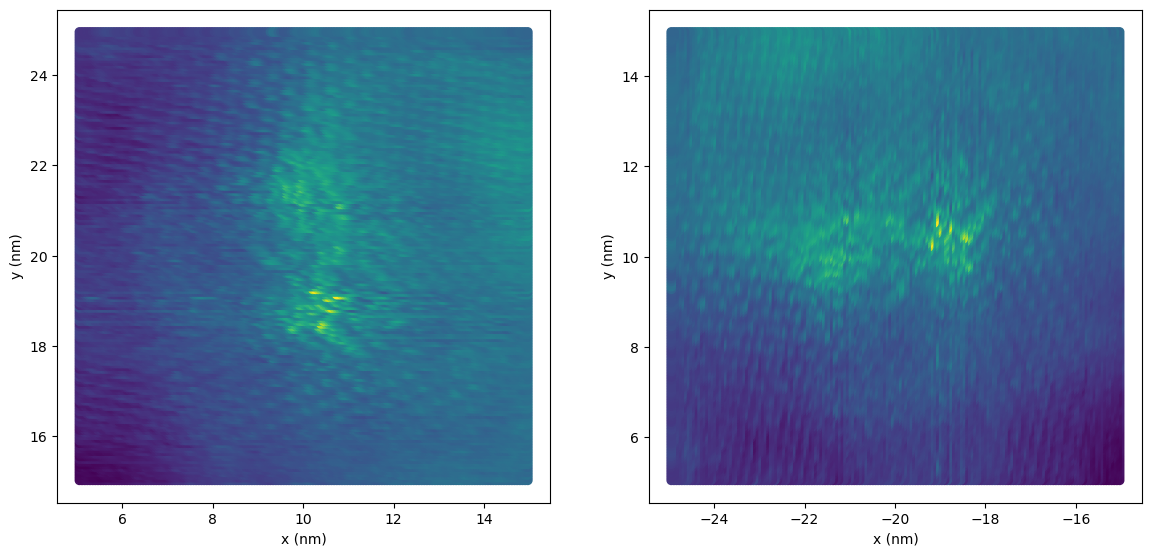

In [87]:
figs, axs = plt.subplots(1, 2, figsize=(14, 7))

#ax1.scatter(sdf['x'], sdf['y'], c=sdf['z'])
axs[0].scatter(sdf['x'], sdf['y'], c=sdf['z'])
axs[0].set_xlabel("x (nm)")
axs[0].set_ylabel("y (nm)")
axs[0].set_aspect('equal')


axs[1].scatter(xr, yr, c=zr)
axs[1].set_xlabel("x (nm)")
axs[1].set_ylabel("y (nm)")
axs[1].set_aspect('equal')

In [88]:
x_unique = np.unique(sdf['x'])
y_unique = np.unique(sdf['y'])

# Create a meshgrid from the unique x and y values
X, Y = np.meshgrid(x_unique, y_unique)

xlin = np.linspace(-5, 5, len(x_unique))
ylin = np.linspace(-5, 5, len(y_unique))

X, Y = np.meshgrid(xlin, ylin)

Z = np.array(sdf['z']).reshape(len(x_unique), len(y_unique))
Z = np.rot90(Z, k=-1)

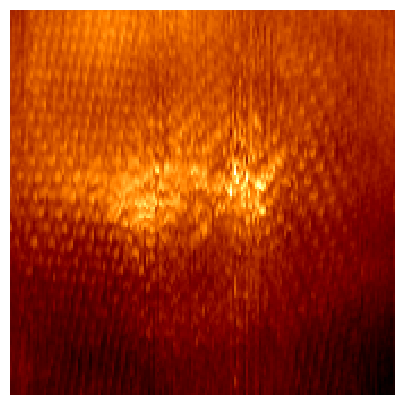

In [89]:
fig2, ax2 = plt.subplots(figsize=(5, 5))

ax2.pcolormesh(X, Y, Z, cmap="afmhot")
ax2.set_aspect('equal')
ax2.set_xlabel("x [nm]")
ax2.set_ylabel("y [nm]")
ax2.set_axis_off()

In [90]:
ftz = np.fft.fft2(Z)
ftz = np.fft.fftshift(ftz)
plz = np.log(np.abs(ftz ** 2))


dx = xlin[1] - xlin[0]
fx = np.fft.fftfreq(len(xlin), dx)
fy = np.fft.fftfreq(len(ylin), dx)
fxs = np.fft.fftshift(fx)
fys = np.fft.fftshift(fy)

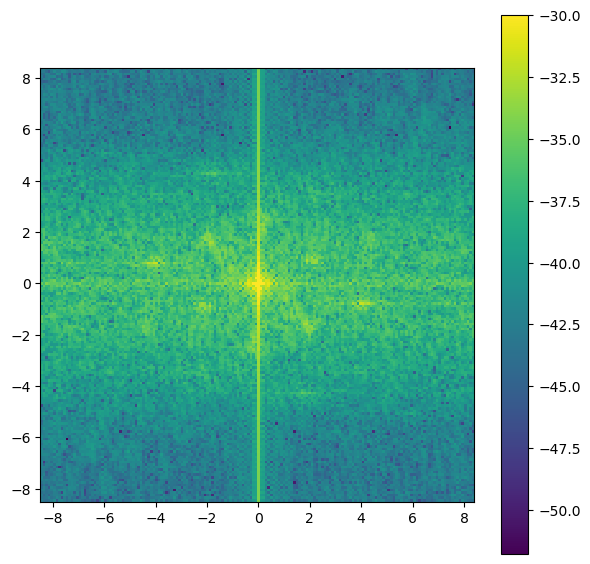

In [91]:
fig3, ax3 = plt.subplots(figsize=(7, 7))

c = ax3.pcolormesh(fxs, fys, plz, vmax=-30)
cbar = plt.colorbar(c)

ax3.set_aspect('equal')

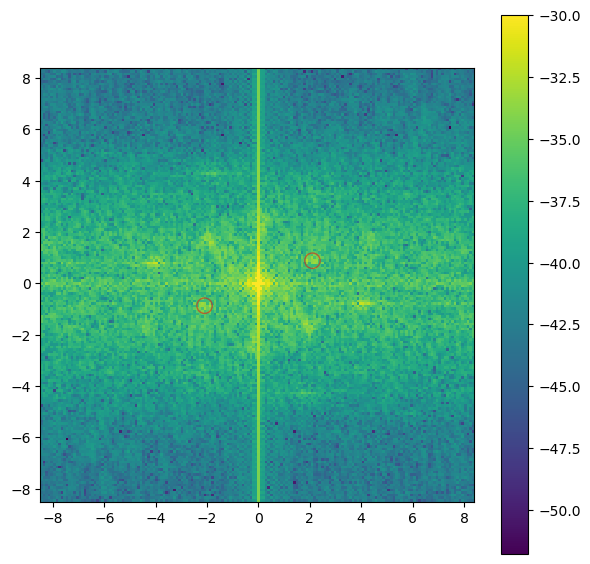

In [105]:
# Choosing where to filter
fig4, ax4 = plt.subplots(figsize=(7, 7))

c = ax4.pcolormesh(fxs, fys, plz, vmax=-30)
cbar = plt.colorbar(c)

#ax4.set_xlim(1, 3)
#ax4.set_ylim(0, 2)
ax4.set_aspect('equal')

x1, y1, r1 = 2.1, 0.875, 0.3
x2, y2, r2 = -2.1, -0.875, 0.3

#x1, y1, r1 = -1.9, 1.6, 0.45
#x2, y2, r2 = 1.9, -1.6, 0.45
#ax4.scatter(2.15, 0.85)
circle1 = plt.Circle((x1, y1), r1, color='red', fill=False, alpha=0.5)
circle2 = plt.Circle((x2, y2), r2, color='red', fill=False, alpha=0.5)
ax4.add_patch(circle1)
ax4.add_patch(circle2)

In [106]:
# Periodic 1D Hann Function
def hann1dp(x, N, x0):
    return np.cos(np.pi * (x-x0)/N) ** 2

def hann2d(x, y, Nx, Ny, x0, y0): 
    val = hann1dp(x, Nx, x0) * hann1dp(y, Ny, y0)

    return np.where((np.abs(x-x0) <= 0.5 * Nx) & (np.abs(y-y0) <= 0.5 * Ny), val, 0)

hann_vec = np.vectorize(hann2d)

In [107]:
# Hann Filtering
ffx, ffy = np.meshgrid(fxs, fys)
hann_z = hann2d(ffx, ffy, 2 * r1, 2 * r1, x1, y1) + hann2d(ffx, ffy, 2 * r2, 2 * r2, x2, y2)

ftzf = ftz * hann_z
plzf = plz * hann_z

z_filtered = np.fft.ifft2(ftzf)
zfls = np.log(np.real(z_filtered * np.conj(z_filtered)))

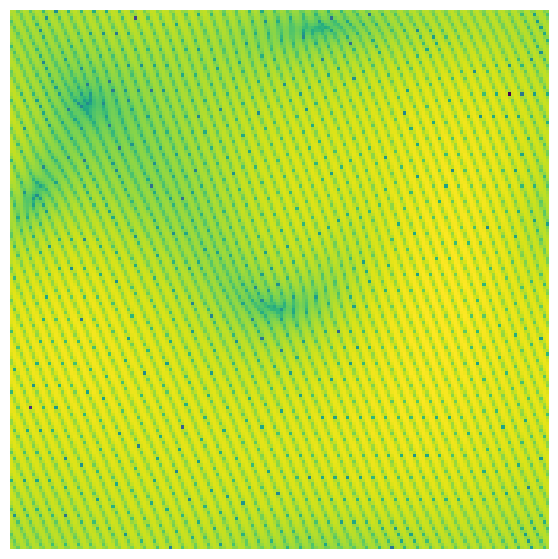

In [109]:
fig3, ax3 = plt.subplots(figsize=(7, 7))

c = ax3.pcolormesh(X, Y, zfls)
#cbar = plt.colorbar(c)

ax3.set_axis_off()

ax3.set_aspect('equal')

fig3.savefig("filtered_stm.png", dpi=400)